<a href="https://colab.research.google.com/github/kanika10-hub/DL_LEARN_LOG/blob/main/Day6/CNN(classifying_images).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET- CIFAR10 , FROM TENSORFLOW KERAS DATASETS

THERE WILL BE 10 CLASSES

WE WILL USE CNN FOR CLASSIFICATION

In [4]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np



In [6]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()


In [7]:
x_train.shape


(50000, 32, 32, 3)

this means 5000 total training images , 32*32 , rgb(3 values)

In [8]:
y_train.shape

(50000, 1)

5000 answers with 1 value i.e classes
 we must reshape the y_train



In [9]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [10]:
y_train=y_train.reshape(-1,)


In [12]:
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

reshaping y_test as well

In [47]:
y_test=y_test.reshape(-1,)

In [13]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [17]:
def plot_sample(x, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

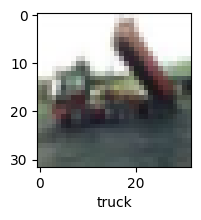

In [18]:
plot_sample(x_train,y_train,2)

In [19]:
x_train=x_train/255.0

In [20]:
x_test=x_test/255.0

BUILDING A ANN FOR IMAGE CLASSIFICATION

In [21]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


COMPILING IT

In [ ]:
ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(x_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 123s 78ms/step - accuracy: 0.5118 - loss: 1.3905
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 123s 78ms/step - accuracy: 0.5245 - loss: 1.3526
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 78ms/step - accuracy: 0.5365 - loss: 1.3167
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 121s 78ms/step - accuracy: 0.5517 - loss: 1.2831
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 149s 82ms/step - accuracy: 0.5604 - loss: 1.2544


making a classification report

In [27]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.70      0.40      0.51      1000
           1       0.77      0.45      0.57      1000
           2       0.30      0.55      0.39      1000
           3       0.39      0.15      0.22      1000
           4       0.51      0.23      0.32      1000
           5       0.32      0.64      0.42      1000
           6       0.46      0.68      0.55      1000
           7       0.64      0.51      0.57      1000
           8       0.69      0.57      0.62      1000
           9       0.57      0.60      0.58      1000

    accuracy                           0.48     10000
   macro avg       0.53      0.48      0.48     10000
weighted avg       0.53      0.48      0.48     10000



now building a CONVOLTIONAL NEURAL NETWORK

In [35]:
cnn=models.Sequential([layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
                       layers.MaxPooling2D((2,2)),
                       layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
                       layers.MaxPooling2D((2,2)),
                       layers.Flatten(),
                       layers.Dense(64,activation='relu'),
                       layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [37]:
cnn.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 43ms/step - accuracy: 0.4664 - loss: 1.4912
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.6009 - loss: 1.1374
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6520 - loss: 0.9992
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.6821 - loss: 0.9172
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7058 - loss: 0.8490
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.7211 - loss: 0.7983
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7373 - loss: 0.7562
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7486 - loss: 0.7149
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 44ms/step - accuracy: 0.7626 - loss: 0.6771
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 41ms/step - accuracy: 0.7731 - loss: 0.6456


here we see that the accuracy of CNN is much greater than ANN ,  CNN are best for image classification and also uses less computation because maxpooling reduces the image dimensions while still preserving the features

In [38]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6944 - loss: 0.9261


[0.9260695576667786, 0.6944000124931335]

In [40]:
y_pred=cnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [42]:
y_pred[:5]

array([[3.65453493e-03, 4.75512716e-05, 7.05650728e-03, 9.02476490e-01,
        4.42019757e-03, 5.89209795e-02, 1.76895931e-02, 6.18534861e-04,
        4.61081881e-03, 5.04768163e-04],
       [3.39854392e-03, 7.64527693e-02, 4.01028183e-06, 8.61731877e-08,
        4.49396254e-08, 9.01562025e-09, 1.00741474e-07, 3.47112761e-09,
        9.19168591e-01, 9.75797244e-04],
       [2.56326655e-03, 2.88613467e-03, 1.55582995e-04, 1.19616231e-03,
        1.68267696e-04, 1.08711225e-04, 2.77998060e-06, 4.65403573e-05,
        9.92201209e-01, 6.71349524e-04],
       [5.04776299e-01, 1.35525148e-02, 4.11889963e-02, 5.35184890e-03,
        2.74540842e-01, 4.01705533e-04, 3.56027507e-04, 1.18538607e-02,
        1.45393774e-01, 2.58408953e-03],
       [1.98931684e-06, 1.35022265e-06, 8.91507603e-03, 1.89801138e-02,
        5.15333831e-01, 6.17738580e-04, 4.56146151e-01, 1.19458946e-06,
        2.64613504e-06, 2.16479137e-08]], dtype=float32)

In [52]:
y_classes=[np.argmax(element)for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [51]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

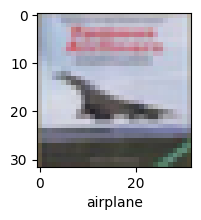

In [49]:
plot_sample(x_test,y_test,3)

In [53]:
classes[y_classes[3]]

'airplane'